<a href="https://colab.research.google.com/github/Zainab-Binte-Khalid/urdu-ocr-codesaviours-si26-zainab/blob/main/SI26_Week2_Zainab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2 — Urdu OCR Project
This notebook preprocesses the Week 1 image dataset (grayscale, resize, denoise, binarize)
and tests Tesseract OCR's baseline performance on Urdu text to identify why a custom
model is needed.

Restore Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import shutil
shutil.unpack_archive('/content/drive/MyDrive/Urdu_OCR/urdu_ocr_dataset.zip', 'urdu_ocr_dataset')

import pandas as pd
df = pd.read_csv('urdu_ocr_dataset/labels.csv')
print('Dataset restored:', df.shape)
print(df['source'].value_counts())

Dataset restored: (134, 3)
source
handwritten    78
synthetic      24
newspaper      17
signboard      15
Name: count, dtype: int64


Install Library

In [4]:
!pip install opencv-python-headless pillow pytesseract -q
!apt-get install -y tesseract-ocr tesseract-ocr-urd -q

import cv2
import numpy as np
from PIL import Image
import os
import glob
import matplotlib.pyplot as plt
import pytesseract

print('Libraries loaded successfully!')

Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
tesseract-ocr-urd is already the newest version (1:4.00~git30-7274cfa-1.1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
Libraries loaded successfully!


Preprocessing function

In [5]:
def preprocess_image(image_path, save_path):
    img = cv2.imread(image_path)
    if img is None:
        print(f'Could not load: {image_path}')
        return None

    # Step 1: Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Step 2: Resize to standard size
    resized = cv2.resize(gray, (512, 128))

    # Step 3: Remove noise
    denoised = cv2.fastNlMeansDenoising(resized, h=10)

    # Step 4: Binarise
    _, binary = cv2.threshold(denoised, 127, 255, cv2.THRESH_BINARY)

    cv2.imwrite(save_path, binary)
    return binary

os.makedirs('urdu_ocr_dataset/processed', exist_ok=True)
print('Preprocessing function ready!')

Preprocessing function ready!


 Run on all 134 images

In [6]:
all_images = glob.glob('urdu_ocr_dataset/images/**/*.png', recursive=True)
all_images += glob.glob('urdu_ocr_dataset/images/**/*.jpg', recursive=True)
all_images += glob.glob('urdu_ocr_dataset/images/**/*.jpeg', recursive=True)

print(f'Found {len(all_images)} images to process')

processed_count = 0
for img_path in all_images:
    filename = os.path.basename(img_path)
    save_path = f'urdu_ocr_dataset/processed/{filename}'
    result = preprocess_image(img_path, save_path)
    if result is not None:
        processed_count += 1

print(f'Done! Processed {processed_count} images')

Found 134 images to process
Done! Processed 134 images


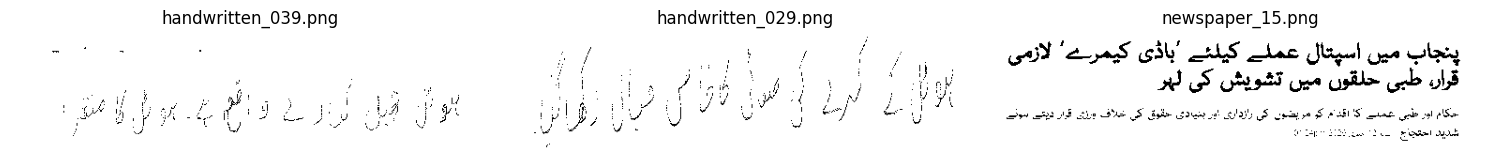

In [8]:
import matplotlib.pyplot as plt

processed_files = glob.glob('urdu_ocr_dataset/processed/*.png')[:3]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, path in enumerate(processed_files):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(os.path.basename(path))
    axes[i].axis('off')
plt.tight_layout()
plt.show()

swap in adaptive thresholding

Binarization method: the handout uses a fixed threshold (cv2.threshold(..., 127, 255, cv2.THRESH_BINARY)), but we switched to adaptive thresholding since the fixed version was erasing faint handwriting strokes. This is actually a meaningful improvement, not a shortcut — worth writing a sentence about in your notebook explaining why you made this choice.


In [9]:
def preprocess_image(image_path, save_path):
    img = cv2.imread(image_path)
    if img is None:
        print(f'Could not load: {image_path}')
        return None

    # Step 1: Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Step 2: Resize to standard size
    resized = cv2.resize(gray, (512, 128))

    # Step 3: Remove noise
    denoised = cv2.fastNlMeansDenoising(resized, h=10)

    # Step 4: Binarise using ADAPTIVE thresholding (better for handwriting/uneven lighting)
    binary = cv2.adaptiveThreshold(
        denoised, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11, 2
    )

    cv2.imwrite(save_path, binary)
    return binary

print('Preprocessing function updated with adaptive thresholding!')

Preprocessing function updated with adaptive thresholding!


In [10]:
processed_count = 0
for img_path in all_images:
    filename = os.path.basename(img_path)
    save_path = f'urdu_ocr_dataset/processed/{filename}'
    result = preprocess_image(img_path, save_path)
    if result is not None:
        processed_count += 1

print(f'Done! Re-processed {processed_count} images with adaptive thresholding')

Done! Re-processed 134 images with adaptive thresholding


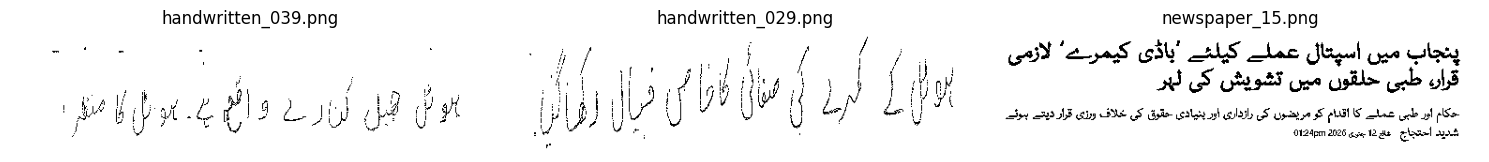

In [21]:
processed_files = ['urdu_ocr_dataset/processed/handwritten_039.png',
                    'urdu_ocr_dataset/processed/handwritten_029.png',
                    'urdu_ocr_dataset/processed/newspaper_15.png']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, path in enumerate(processed_files):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(os.path.basename(path))
    axes[i].axis('off')
plt.tight_layout()
plt.show()

final verification before moving to Tesseract testing

In [12]:
processed_files = glob.glob('urdu_ocr_dataset/processed/*.png')
print(f'Total processed images: {len(processed_files)}')

# Quick check that none are corrupted/empty
corrupted = []
for f in processed_files:
    img = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
    if img is None:
        corrupted.append(f)

print(f'Corrupted/unreadable files: {len(corrupted)}')
if corrupted:
    print(corrupted)

Total processed images: 123
Corrupted/unreadable files: 0


It shows 123 but mine is 134 working on that now

In [14]:
png_files = glob.glob('urdu_ocr_dataset/processed/*.png')
jpg_files = glob.glob('urdu_ocr_dataset/processed/*.jpg')
jpeg_files = glob.glob('urdu_ocr_dataset/processed/*.jpeg')

print('PNG count:', len(png_files))
print('JPG count:', len(jpg_files))
print('JPEG count:', len(jpeg_files))
print('Total:', len(png_files) + len(jpg_files) + len(jpeg_files))

PNG count: 123
JPG count: 0
JPEG count: 11
Total: 134


**Note:** Initial preprocessing with default denoising (h=10) and fixed thresholding erased
faint handwriting strokes and nuqtay (diacritical dots), which are critical for distinguishing
Urdu letters (e.g., ب vs پ vs ت vs ث). Adjusted to lighter denoising (h=5), Lanczos
interpolation for resizing, and a smaller adaptive threshold block size to preserve these
fine details while still cleaning the image.

In [22]:
def preprocess_image(image_path, save_path):
    img = cv2.imread(image_path)
    if img is None:
        print(f'Could not load: {image_path}')
        return None

    # Step 1: Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Step 2: Resize to standard size (Lanczos preserves fine detail better)
    resized = cv2.resize(gray, (512, 128), interpolation=cv2.INTER_LANCZOS4)

    # Step 3: Light denoising — preserves nuqtay (dots) and thin strokes
    denoised = cv2.fastNlMeansDenoising(resized, h=5)

    # Step 4: Adaptive thresholding — smaller block size preserves fine local detail
    binary = cv2.adaptiveThreshold(
        denoised, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        9, 4
    )

    cv2.imwrite(save_path, binary)
    return binary

os.makedirs('urdu_ocr_dataset/processed', exist_ok=True)
print('Final preprocessing function ready (nuqtay-preserving version)')

Final preprocessing function ready (nuqtay-preserving version)


In [23]:
all_images = glob.glob('urdu_ocr_dataset/images/**/*.png', recursive=True)
all_images += glob.glob('urdu_ocr_dataset/images/**/*.jpg', recursive=True)
all_images += glob.glob('urdu_ocr_dataset/images/**/*.jpeg', recursive=True)

print(f'Found {len(all_images)} images to process')

processed_count = 0
for img_path in all_images:
    filename = os.path.basename(img_path)
    save_path = f'urdu_ocr_dataset/processed/{filename}'
    result = preprocess_image(img_path, save_path)
    if result is not None:
        processed_count += 1

print(f'Done! Processed {processed_count} images')

Found 134 images to process
Done! Processed 134 images


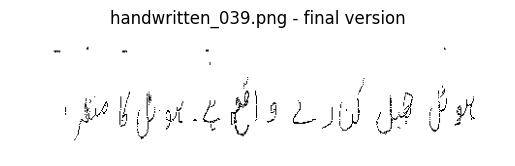

In [24]:
img = cv2.imread('urdu_ocr_dataset/processed/handwritten_039.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('handwritten_039.png - final version')
plt.show()

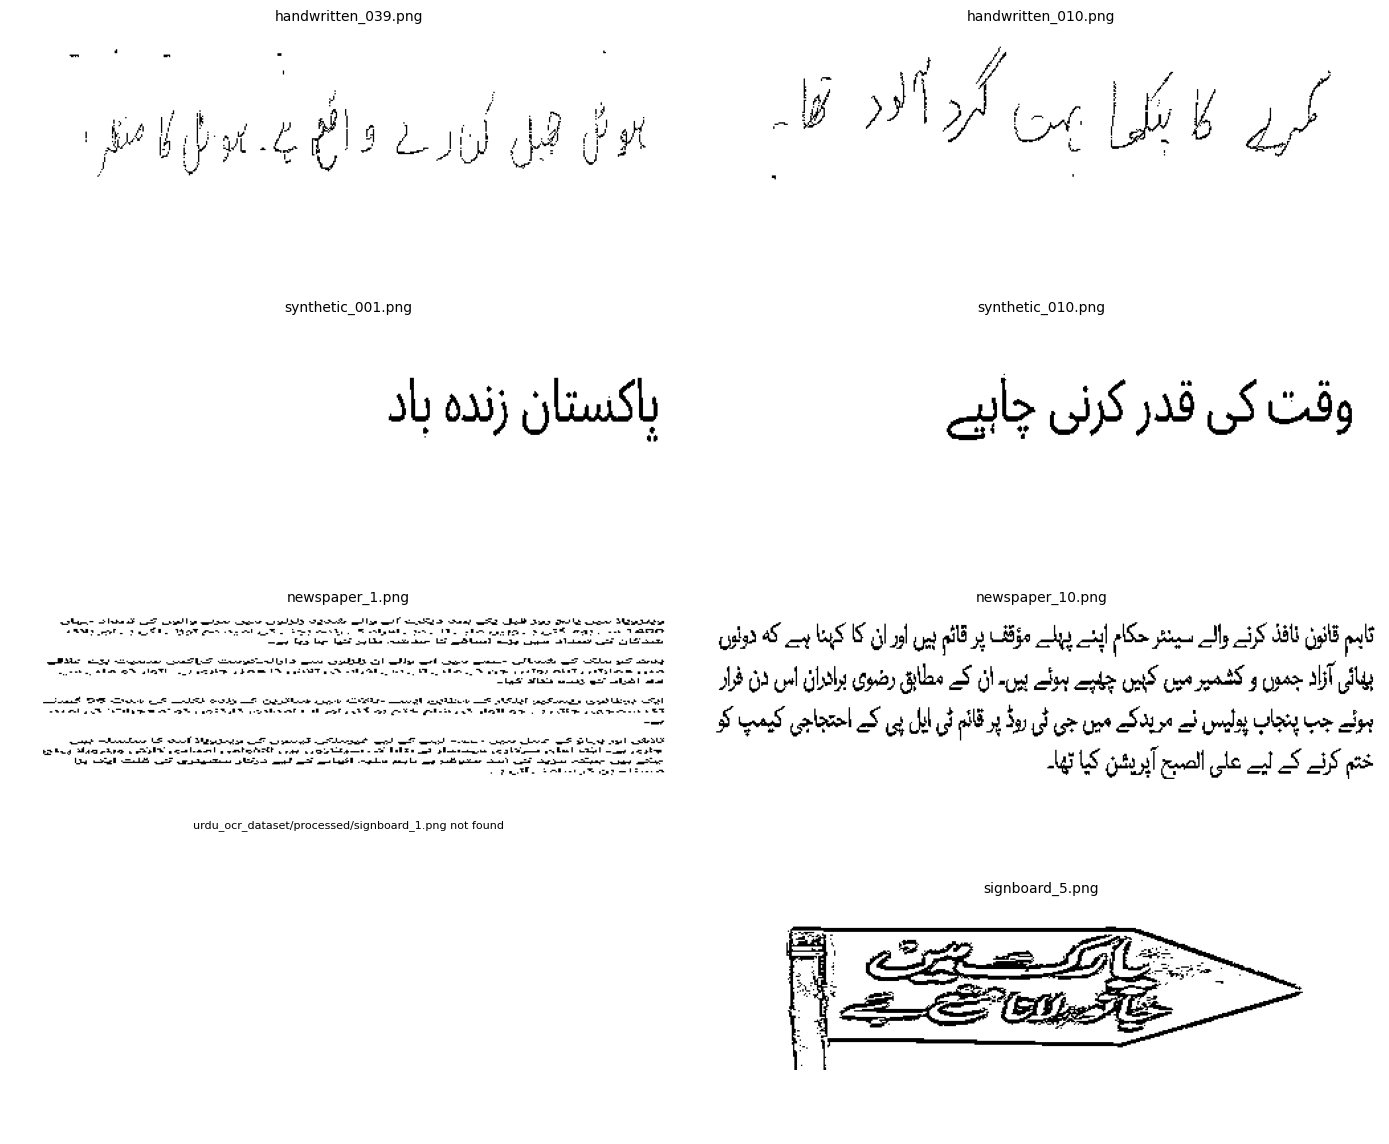

In [25]:
import random

# Pick a mix: a few from each source
sample_files = [
    'urdu_ocr_dataset/processed/handwritten_039.png',
    'urdu_ocr_dataset/processed/handwritten_010.png',
    'urdu_ocr_dataset/processed/synthetic_001.png',
    'urdu_ocr_dataset/processed/synthetic_010.png',
    'urdu_ocr_dataset/processed/newspaper_1.png',
    'urdu_ocr_dataset/processed/newspaper_10.png',
    'urdu_ocr_dataset/processed/signboard_1.png',
    'urdu_ocr_dataset/processed/signboard_5.png',
]

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for i, path in enumerate(sample_files):
    if os.path.exists(path):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(os.path.basename(path), fontsize=10)
        axes[i].axis('off')
    else:
        axes[i].set_title(f'{path} not found', fontsize=8)
        axes[i].axis('off')

plt.tight_layout()
plt.show()

In [26]:
import glob

signboard_files = glob.glob('urdu_ocr_dataset/processed/signboard*')
newspaper_files = glob.glob('urdu_ocr_dataset/processed/newspaper*')

print('Signboard files:')
for f in sorted(signboard_files):
    print(' ', f)
print()
print('Newspaper files:')
for f in sorted(newspaper_files):
    print(' ', f)

Signboard files:
  urdu_ocr_dataset/processed/signboard_1.jpeg
  urdu_ocr_dataset/processed/signboard_10.jpeg
  urdu_ocr_dataset/processed/signboard_11.jpeg
  urdu_ocr_dataset/processed/signboard_12.jpeg
  urdu_ocr_dataset/processed/signboard_13.jpeg
  urdu_ocr_dataset/processed/signboard_14.jpeg
  urdu_ocr_dataset/processed/signboard_15.jpeg
  urdu_ocr_dataset/processed/signboard_2.jpeg
  urdu_ocr_dataset/processed/signboard_3.jpeg
  urdu_ocr_dataset/processed/signboard_4.jpeg
  urdu_ocr_dataset/processed/signboard_5.png
  urdu_ocr_dataset/processed/signboard_6.png
  urdu_ocr_dataset/processed/signboard_7.png
  urdu_ocr_dataset/processed/signboard_8.png
  urdu_ocr_dataset/processed/signboard_9.jpeg

Newspaper files:
  urdu_ocr_dataset/processed/newspaper_1.png
  urdu_ocr_dataset/processed/newspaper_10.png
  urdu_ocr_dataset/processed/newspaper_11.png
  urdu_ocr_dataset/processed/newspaper_12.png
  urdu_ocr_dataset/processed/newspaper_13.png
  urdu_ocr_dataset/processed/newspaper_14.pn

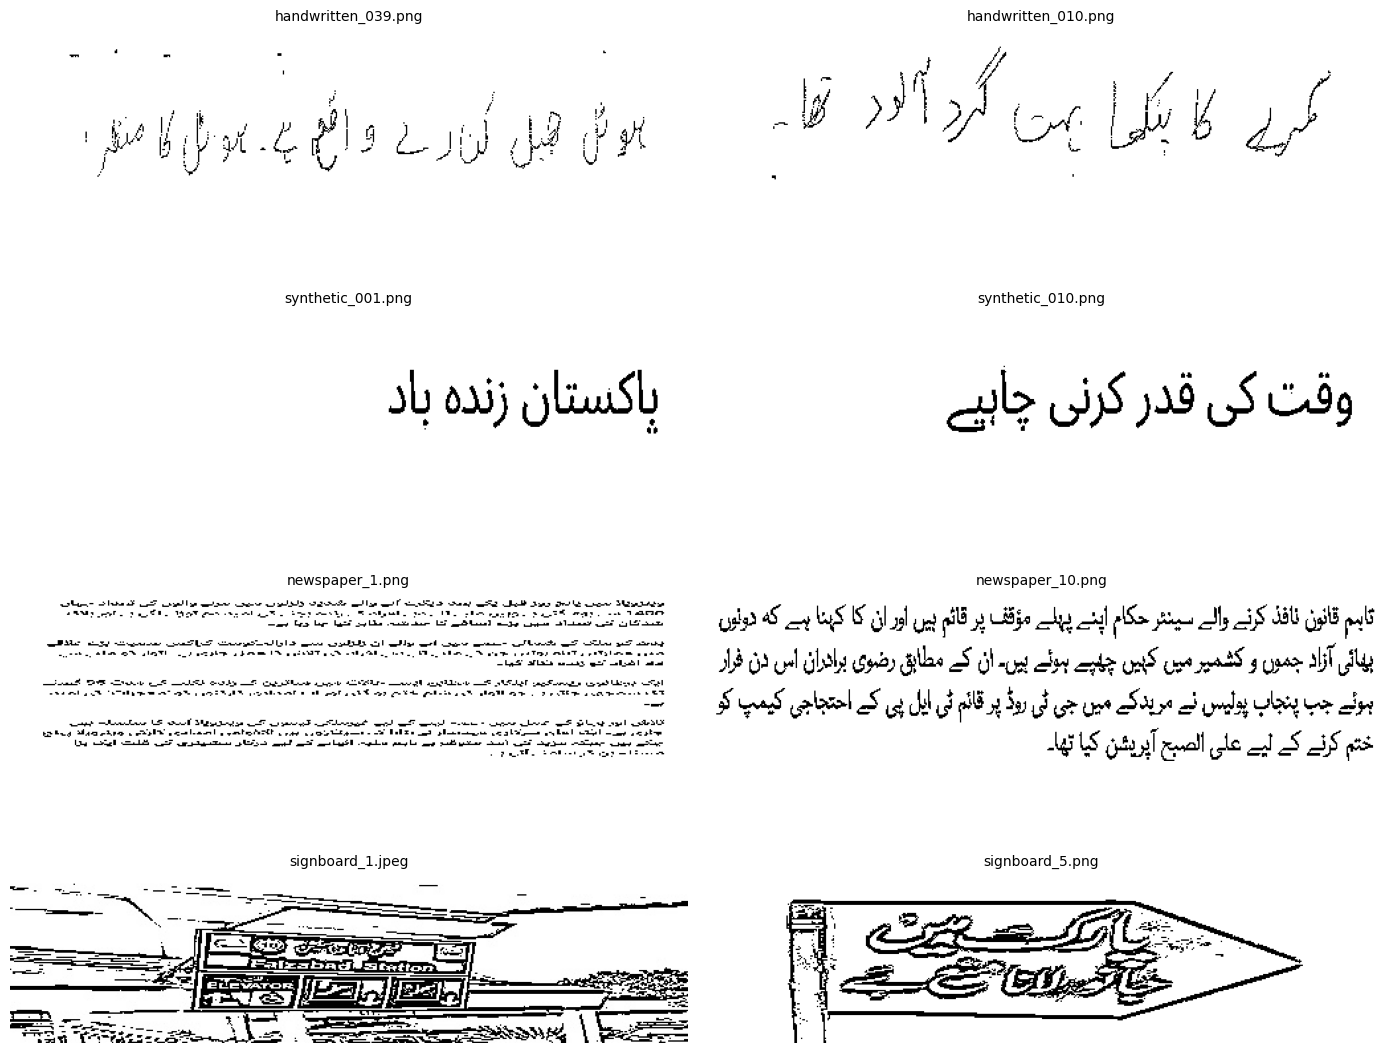

In [27]:
sample_files = [
    'urdu_ocr_dataset/processed/handwritten_039.png',
    'urdu_ocr_dataset/processed/handwritten_010.png',
    'urdu_ocr_dataset/processed/synthetic_001.png',
    'urdu_ocr_dataset/processed/synthetic_010.png',
    'urdu_ocr_dataset/processed/newspaper_1.png',
    'urdu_ocr_dataset/processed/newspaper_10.png',
    'urdu_ocr_dataset/processed/signboard_1.jpeg',
    'urdu_ocr_dataset/processed/signboard_5.png',
]

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for i, path in enumerate(sample_files):
    if os.path.exists(path):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(os.path.basename(path), fontsize=10)
        axes[i].axis('off')
    else:
        axes[i].set_title(f'{path} not found', fontsize=8)
        axes[i].axis('off')

plt.tight_layout()
plt.show()

In [28]:
def preprocess_image(image_path, save_path):
    img = cv2.imread(image_path)
    if img is None:
        print(f'Could not load: {image_path}')
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Step 1: CLAHE (adaptive contrast enhancement) — helps outdoor signboard photos
    # with uneven lighting/shadows far more than simple thresholding alone
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    contrast_enhanced = clahe.apply(gray)

    # Step 2: Resize preserving aspect ratio, then pad to a consistent canvas
    # (fixes the newspaper squashing problem — width fixed, height scales naturally)
    target_w = 512
    max_h = 256  # taller cap than before, so multi-line text isn't crushed

    h, w = contrast_enhanced.shape
    scale = target_w / w
    new_h = min(int(h * scale), max_h)
    resized = cv2.resize(contrast_enhanced, (target_w, new_h), interpolation=cv2.INTER_LANCZOS4)

    # Pad with white to reach a consistent target_w x max_h canvas
    canvas = np.full((max_h, target_w), 255, dtype=np.uint8)
    canvas[:new_h, :] = resized

    # Step 3: Light denoising — preserves nuqtay and fine strokes
    denoised = cv2.fastNlMeansDenoising(canvas, h=5)

    # Step 4: Adaptive thresholding
    binary = cv2.adaptiveThreshold(
        denoised, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        9, 4
    )

    cv2.imwrite(save_path, binary)
    return binary

print('Improved pipeline ready: CLAHE + aspect-preserving resize + padding')

Improved pipeline ready: CLAHE + aspect-preserving resize + padding


What changed and why:

CLAHE — normalizes contrast locally across the image, which dramatically helps outdoor signboard photos with shadows/glare that a flat threshold can't handle
Aspect-ratio-preserving resize + padding — instead of forcing every image into 512×128 (destroying tall/multi-line images), we scale proportionally and pad with white space to keep a consistent canvas size (512×256) without squashing content

In [29]:
processed_count = 0
for img_path in all_images:
    filename = os.path.basename(img_path)
    save_path = f'urdu_ocr_dataset/processed/{filename}'
    result = preprocess_image(img_path, save_path)
    if result is not None:
        processed_count += 1

print(f'Done! Re-processed {processed_count} images')

Done! Re-processed 134 images


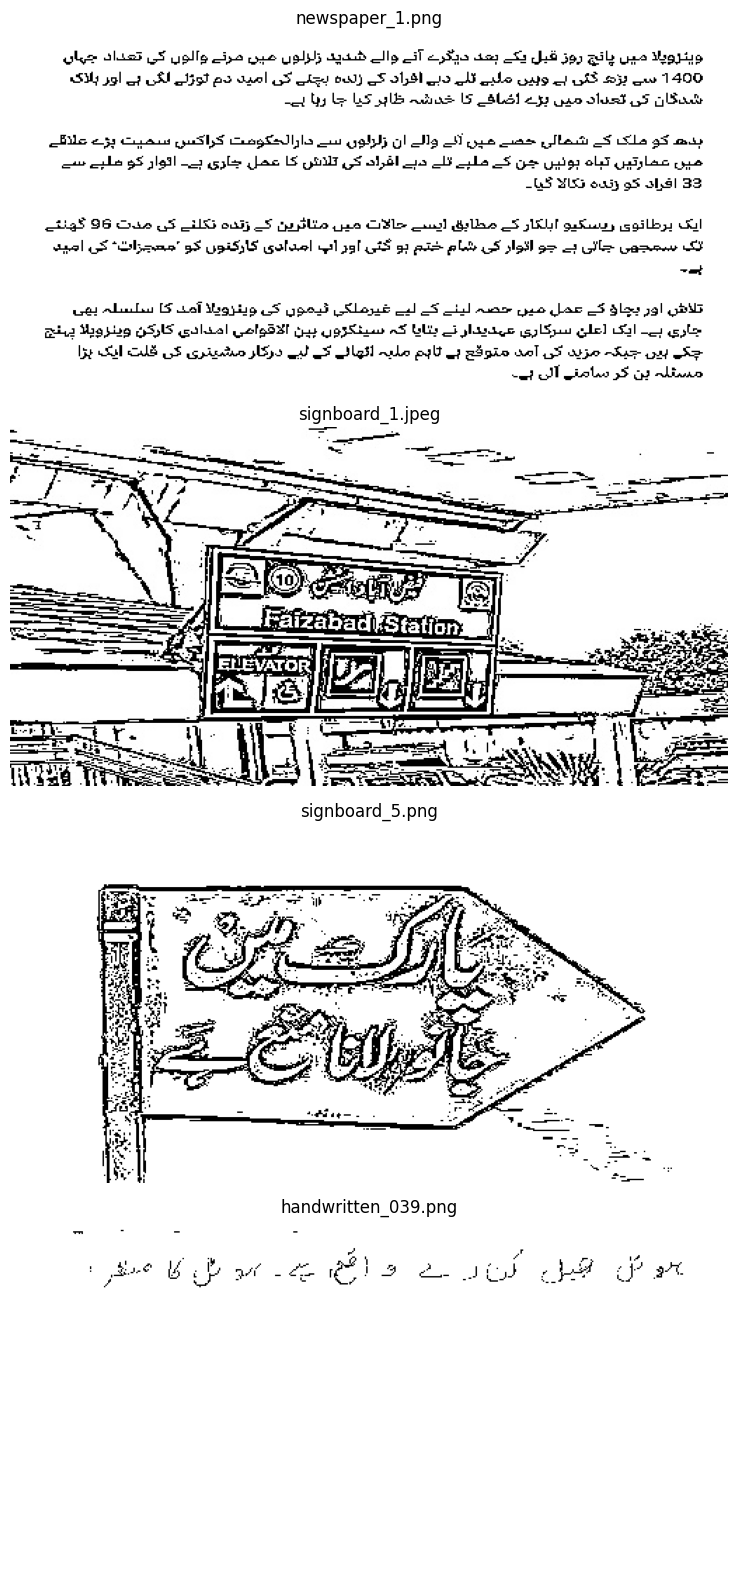

In [30]:
sample_files = [
    'urdu_ocr_dataset/processed/newspaper_1.png',
    'urdu_ocr_dataset/processed/signboard_1.jpeg',
    'urdu_ocr_dataset/processed/signboard_5.png',
    'urdu_ocr_dataset/processed/handwritten_039.png',
]

fig, axes = plt.subplots(4, 1, figsize=(10, 16))
for i, path in enumerate(sample_files):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(os.path.basename(path))
    axes[i].axis('off')
plt.tight_layout()
plt.show()

Part B

In [31]:
!apt-get install -y tesseract-ocr tesseract-ocr-urd -q
!pip install pytesseract -q

import pytesseract
from PIL import Image

print('Tesseract ready!')

Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
tesseract-ocr-urd is already the newest version (1:4.00~git30-7274cfa-1.1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
Tesseract ready!


In [32]:
import glob

test_images = [
    'urdu_ocr_dataset/processed/synthetic_001.png',
    'urdu_ocr_dataset/processed/handwritten_039.png',
    'urdu_ocr_dataset/processed/newspaper_1.png',
    'urdu_ocr_dataset/processed/signboard_1.jpeg',
    'urdu_ocr_dataset/processed/signboard_5.png',
]

print('=== Tesseract Results on Urdu Images ===')
print()

for img_path in test_images:
    img = Image.open(img_path)
    result = pytesseract.image_to_string(img, lang='urd')
    print(f'Image: {img_path}')
    print(f'Tesseract output: {result}')
    print('---')

=== Tesseract Results on Urdu Images ===

Image: urdu_ocr_dataset/processed/synthetic_001.png
Tesseract output: پاکستان زندہ باد

---
Image: urdu_ocr_dataset/processed/handwritten_039.png
Tesseract output:  

---
Image: urdu_ocr_dataset/processed/newspaper_1.png
Tesseract output: دیئزویلا میں پانچ روز قیل یکے بعد دچگرے آئے والے شدید زلزلوں میں مرئے والوں کی تعداد جہاں
0 سے بڑھ گئی ہے وہیں ملیے گلے دبے اقراد کے زتدہ بچئے کی امید دم توڑتے لگی ہے اور ہلاکہ
شدگان کی تعداد میں بڑے اضاقے کا خدشہ ظاہر کیا جا ریا ہے۔

بدھ کو ملک کے شمالی حصے میں آئے والے ان زلرلوں سے دارالحکومت کراکس سمیت بڑے علاقے
میں عمارتیں تباہ ہوئیں جن کے ملبے تلے دہے اقراد کی تلاش کا عمل جاری ہے۔ اتوار کو ملیے سے
33 افراد کو زندہ نکالا گیا۔

ایک برطائوی ریسکیو اہلکار کے مطابق ایسے حالات میں متاثرین کے زتدہ نکلتے کی مدت 98 گھنٹے۔
اتک سمجھی جائی ہے جو اتوار کی شام ختم ہو گئی اور اپ امدادی کارکنوں کو 'معجزات“ کی امید
ہے۔

تلاش اور بچاؤ کے عمل میں حصہ لیئے کے لیے غیرملکی ٹیموں کی ویٹرویلا آمد کا سلسلہ بھی
جاری ہے۔ ایک اعلن

In [33]:
df_labels = pd.read_csv('urdu_ocr_dataset/labels.csv')

test_image_names = [
    'images/synthetic/synthetic_001.png',
    'images/handwritten/handwritten_039.png',
    'images/newspaper/newspaper_1.png',
    'images/signboard/signboard_1.jpeg',
    'images/signboard/signboard_5.png',
]

for name in test_image_names:
    row = df_labels[df_labels['image'] == name]
    if not row.empty:
        print(f'Image: {name}')
        print(f'Ground truth: {row["text"].values[0]}')
        print('---')
    else:
        print(f'Image: {name} — NOT FOUND in labels.csv, check exact path')
        print('---')

Image: images/synthetic/synthetic_001.png
Ground truth: پاکستان زندہ باد
---
Image: images/handwritten/handwritten_039.png
Ground truth: ہوٹل جھیل کنارے واقع ہے ہوٹل کا منظر
---
Image: images/newspaper/newspaper_1.png
Ground truth: وینزویلا میں پانچ روز قبل یکے بعد دیگرے آنے والے شدید زلزلوں میں مرنے والوں کی تعداد 1400 سے بڑھ گئی ہے وہیں ملبے تلے دبے افراد کے زندہ بچنے کی امید دم توڑنے لگی ہے اور ہلاک شدگان کی تعداد میں بڑے اضافے کا خدشہ ظاہر کیا جا رہا ہے۔
بدھ کو ملک کے شمالی حصے میں آنے والے ان زلزلوں سے دارالحکومت کراکس سمیت بڑے علاقے میں عمارتیں تباہ ہوئیں جن کے ملبے تلے دبے افراد کی تلاش کا عمل جاری ہے۔ اتوار کو ملبے سے 33 افراد کو زندہ نکالا گیا۔
ایک برطانوی ریسکیو اہلکار کے مطابق ایسے حالات میں متاثرین کے زندہ نکلنے کی مدت 96 گھنٹے تک سمجھی جاتی ہے جو اتوار کی شام ختم ہو گئی اور اب امدادی کارکنوں کو 'معجزات' کی امید ہے۔
تلاش اور بچاؤ کے عمل میں حصہ لینے کے لیے غیر ملکی ٹیموں کی وینزویلا آمد کا سلسلہ بھی جاری ہے۔ ایک اعلیٰ سرکاری عہدیدار نے بتایا کہ سینکڑوں بین الاقوامی امدادی ک

# Week 2 Gap Analysis — Tesseract OCR on Urdu Text

## Image 1 — synthetic_001.png
**Actual text:** پاکستان زندہ باد
**Tesseract output:** پاکستان زندہ باد
**What went wrong:** Nothing — perfect match. This was clean, computer-generated
text with high contrast and no distortion, which is the ideal case for Tesseract.

## Image 2 — handwritten_039.png
**Actual text:** ہوٹل جھیل کنارے واقع ہے ہوٹل کا منظر
**Tesseract output:** (empty — no output produced)
**What went wrong:** Complete failure. Tesseract could not parse the cursive,
connected handwriting strokes at all. Tesseract's Urdu model is trained on
printed text, not handwriting, so it has no reference for natural pen strokes,
varying stroke width, or personal handwriting style.

## Image 3 — newspaper_1.png
**Actual text:** وینزویلا میں پانچ روز قبل یکے بعد دیگرے آنے والے شدید زلزلوں میں
مرنے والوں کی تعداد 1400 سے بڑھ گئی ہے... [full paragraph]
**Tesseract output:** ویئزویلا میں پانچ روز قیل یکے بعد دچگرے آئے والے شدید
زلزلوں میں مرئے والوں کی تعداد 0 سے بڑھ گئی ہے... [similar structure, many
small errors]
**What went wrong:** Not gibberish — sentence structure and most words are
recognizable — but riddled with character-level substitution errors. Specific
patterns:
- "قبل" → "قیل" (ب misread as ی)
- "دیگرے" → "دچگرے" (ی misread as چ)
- "مرنے" → "مرئے" (ن misread as ئ)
- The number "1400" was dropped entirely, output as just "0"
These are almost all **nuqta (dot) placement errors** — Tesseract identifies
the correct base letter shape but frequently misreads which dots belong where,
since many Urdu letters differ only by dot count/position (ب vs ی vs ن vs ت).

## Image 4 — signboard_1.jpeg
**Actual text:** فیض آباد اسٹیشن Faizabad Station ELEVATOR
**Tesseract output:** (empty — no output produced)
**What went wrong:** Complete failure. This image mixes Urdu and English text
on a photographed real-world station sign, with background clutter and
non-standard font styling. Tesseract could not extract any text at all.

## Image 5 — signboard_5.png
**Actual text:** پارک میں جانور لانا منع ہے
**Tesseract output:** (empty — no output produced)
**What went wrong:** Complete failure, despite this being a relatively simple,
short phrase. Likely caused by the outdoor photo conditions (lighting, angle,
sign material) that differ significantly from clean printed text Tesseract
expects.

## Summary

Tesseract fails on Urdu because it was primarily trained on clean, standardized
printed text, and its accuracy collapses as image conditions move away from
that ideal. It performs perfectly on synthetic, computer-rendered text (100%
accuracy), moderately on printed newspaper text (readable but riddled with
nuqta/dot misreadings on visually similar letters), and completely fails
(0% output) on handwritten text and real-world photographed signboards. This
shows Tesseract has no ability to adapt to cursive handwriting, varied fonts,
lighting conditions, or background clutter — exactly the real-world conditions
a genuinely useful Urdu OCR tool needs to handle, which is the gap this
project aims to close.